# CMP461 Pattern Recognition - Midterm Project
## Phase 3: CNN (Convolutional Neural Networks) Experimental Design

**Author:** Efe Yaşar  
**Student ID:** 210408030

--- 

### Why CNN? / Neden CNN?
Unlike MLP, CNNs maintain spatial hierarchy. By using Convolution and Pooling layers, they learn local patterns and textures (like fur patterns or snake scales) which are absent in flattened MLP inputs. Here we test 5 variations over 15 epochs each.

MLP'den farklı olarak CNN'ler mekansal hiyerarşiyi korur. Konvolüsyon ve Havuzlama katmanlarını kullanarak, düzleştirilmiş MLP girişlerinde bulunmayan yerel desenleri ve dokuları (tüy desenleri veya yılan pulları gibi) öğrenirler. Burada her biri 15 epok süren 5 farklı varyasyonu test ediyoruz.

In [1]:
# --- STEP 1: Imports and Data Loading ---
# --- ADIM 1: Kütüphaneler ve Veri Yükleme ---

import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
import seaborn as sns
from sklearn.metrics import confusion_matrix

RESULTS_DIR = "results/cnn"
os.makedirs(RESULTS_DIR, exist_ok=True)

print("📊 Loading preprocessed data... / Veriler yükleniyor...")
data = np.load("preprocessed_data.npz")
X_train, y_train = data["X_train"], data["y_train"]
X_val, y_val = data["X_val"], data["y_val"]
X_test, y_test = data["X_test"], data["y_test"]

# CNN expects (Height, Width, Channels) - Already matched / CNN (Yükseklik, Genişlik, Kanal) bekler - Zaten uygun
input_shape = (128, 128, 3)
classes = ["Cats", "Dogs", "Snakes"]

print("✅ Data loaded successfully for CNN experiments.")

/Users/efe/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


📊 Loading preprocessed data... / Veriler yükleniyor...
✅ Data loaded successfully for CNN experiments.


In [2]:
# --- STEP 2: CNN Architecture Factory ---
# --- ADIM 2: CNN Mimari Fabrikası ---

def build_cnn(config):
    """
    Constructs a CNN based on the provided configuration.
    Verilen yapılandırmaya göre bir CNN oluşturur.
    """
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))
    
    # Feature Extraction Part / Öznitelik Çıkarım Bölümü
    for filters in config['filters']:
        model.add(layers.Conv2D(filters, config['kernel_size'], padding='same', activation='relu'))
        
        if config.get('batch_norm'):
            model.add(layers.BatchNormalization())
            
        if config['pooling'] == 'max':
            model.add(layers.MaxPooling2D((2, 2)))
        else:
            model.add(layers.AveragePooling2D((2, 2)))
            
    model.add(layers.Flatten())
    
    # Classification Part / Sınıflandırma Bölümü
    for units in config['dense_units']:
        model.add(layers.Dense(units, activation='relu'))
        if config.get('dropout'):
            model.add(layers.Dropout(config['dropout']))
            
    model.add(layers.Dense(3, activation='softmax'))
    
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# 5 Varyasyon / 5 Variations
experiments = [
    {"name": "CNN_V1_Base", "filters": [32, 64], "kernel_size": (3,3), "pooling": "max", "dense_units": [64]},
    {"name": "CNN_V2_LargeKernel", "filters": [32, 64], "kernel_size": (5,5), "pooling": "max", "dense_units": [64]},
    {"name": "CNN_V3_Deep", "filters": [32, 64, 128, 256], "kernel_size": (3,3), "pooling": "max", "dense_units": [128]},
    {"name": "CNN_V4_AvgPool", "filters": [32, 64], "kernel_size": (3,3), "pooling": "avg", "dense_units": [64]},
    {"name": "CNN_V5_Optimized", "filters": [32, 64, 128], "kernel_size": (3,3), "pooling": "max", "dense_units": [128], "batch_norm": True, "dropout": 0.3}
]


🚀 Starting CNN Experiment: CNN_V1_Base...
Epoch 1/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 9s 118ms/step - accuracy: 0.3921 - loss: 1.5046 - val_accuracy: 0.5844 - val_loss: 0.9235
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 102ms/step - accuracy: 0.6295 - loss: 0.8093 - val_accuracy: 0.6000 - val_loss: 0.7643
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - accuracy: 0.7571 - loss: 0.5649 - val_accuracy: 0.6156 - val_loss: 0.8057
Epoch 4/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - accuracy: 0.8222 - loss: 0.4832 - val_accuracy: 0.7022 - val_loss: 0.7538
Epoch 5/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - accuracy: 0.9142 - loss: 0.2837 - val_accuracy: 0.6756 - val_loss: 0.7997
Epoch 6/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 105ms/step - accuracy: 0.9547 - loss: 0.1745 - val_accuracy: 0.6622 - val_loss: 0.8978
Epoch 7/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - accuracy: 0.9730 - loss: 0.1136 - val_accuracy: 0.6378 - val_loss: 1.1149
Epoch 8/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - accurac

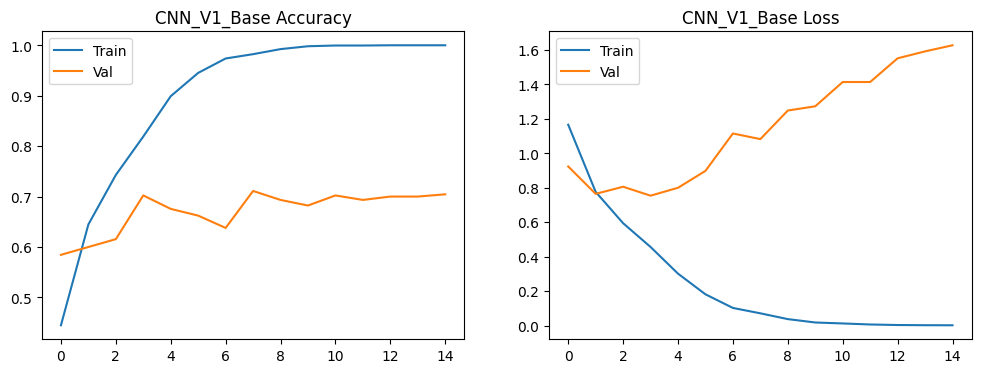

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


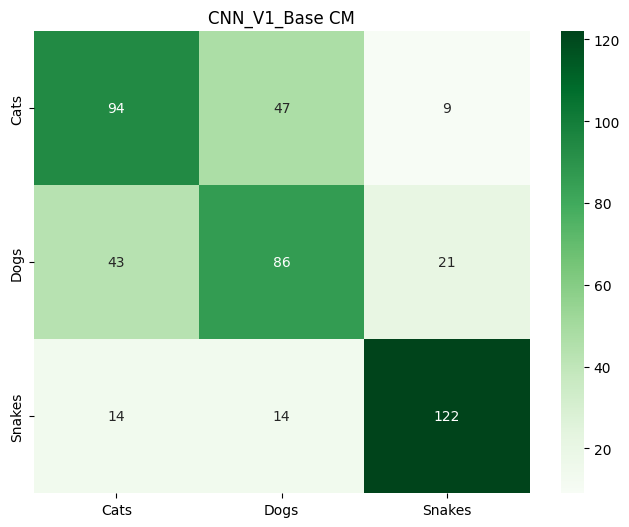


🚀 Starting CNN Experiment: CNN_V2_LargeKernel...
Epoch 1/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 14s 201ms/step - accuracy: 0.3528 - loss: 1.3496 - val_accuracy: 0.5289 - val_loss: 0.9687
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 190ms/step - accuracy: 0.5528 - loss: 0.9061 - val_accuracy: 0.6089 - val_loss: 0.8550
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 184ms/step - accuracy: 0.6294 - loss: 0.8007 - val_accuracy: 0.6156 - val_loss: 0.7946
Epoch 4/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 185ms/step - accuracy: 0.7380 - loss: 0.6290 - val_accuracy: 0.6422 - val_loss: 0.7924
Epoch 5/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 189ms/step - accuracy: 0.8223 - loss: 0.4731 - val_accuracy: 0.6133 - val_loss: 1.0540
Epoch 6/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 186ms/step - accuracy: 0.8846 - loss: 0.3448 - val_accuracy: 0.6311 - val_loss: 0.9977
Epoch 7/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 188ms/step - accuracy: 0.9190 - loss: 0.2309 - val_accuracy: 0.6200 - val_loss: 1.2252
Epoch 8/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 185ms

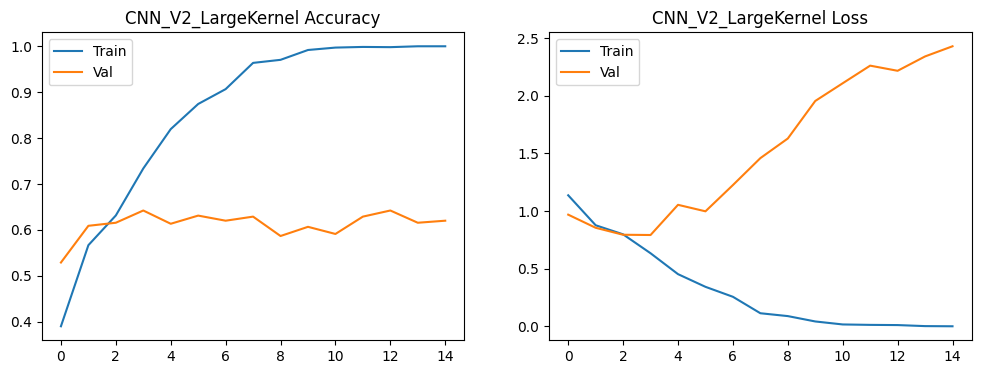

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step


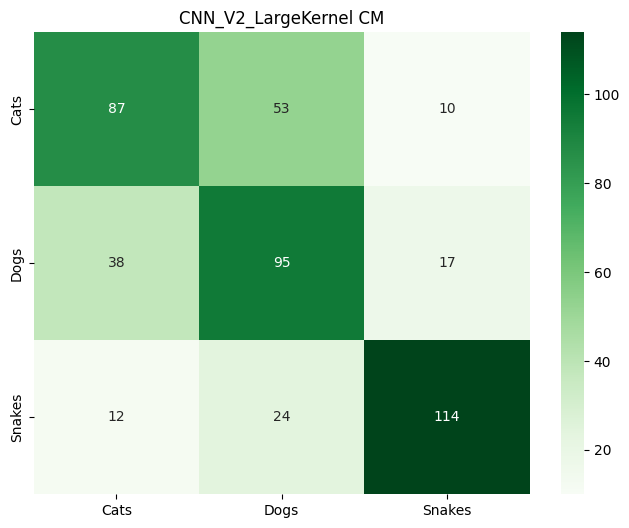


🚀 Starting CNN Experiment: CNN_V3_Deep...
Epoch 1/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 14s 198ms/step - accuracy: 0.3503 - loss: 1.1228 - val_accuracy: 0.5600 - val_loss: 0.9327
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 194ms/step - accuracy: 0.6068 - loss: 0.8339 - val_accuracy: 0.6444 - val_loss: 0.7805
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 190ms/step - accuracy: 0.6079 - loss: 0.7748 - val_accuracy: 0.5733 - val_loss: 0.8571
Epoch 4/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 192ms/step - accuracy: 0.6625 - loss: 0.7434 - val_accuracy: 0.6778 - val_loss: 0.7150
Epoch 5/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 14s 219ms/step - accuracy: 0.7089 - loss: 0.6572 - val_accuracy: 0.6844 - val_loss: 0.7386
Epoch 6/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 197ms/step - accuracy: 0.7399 - loss: 0.6026 - val_accuracy: 0.6600 - val_loss: 0.6770
Epoch 7/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 195ms/step - accuracy: 0.7775 - loss: 0.5369 - val_accuracy: 0.6844 - val_loss: 0.6851
Epoch 8/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 14s 207ms/step -

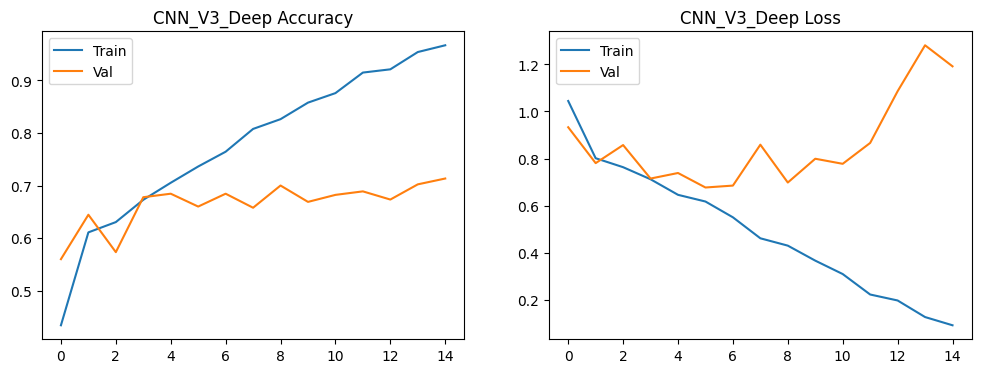

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step


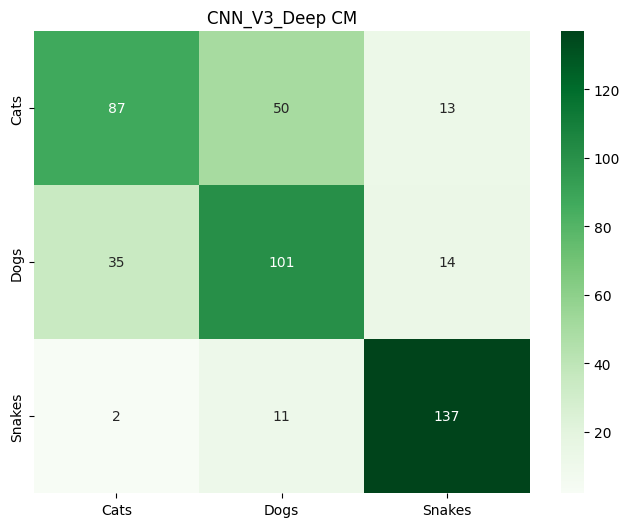


🚀 Starting CNN Experiment: CNN_V4_AvgPool...
Epoch 1/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 101ms/step - accuracy: 0.3875 - loss: 1.4488 - val_accuracy: 0.5489 - val_loss: 0.9503
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - accuracy: 0.6030 - loss: 0.8680 - val_accuracy: 0.5778 - val_loss: 0.9193
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - accuracy: 0.6975 - loss: 0.6834 - val_accuracy: 0.6933 - val_loss: 0.7342
Epoch 4/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - accuracy: 0.7526 - loss: 0.5985 - val_accuracy: 0.6756 - val_loss: 0.7786
Epoch 5/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - accuracy: 0.8184 - loss: 0.4721 - val_accuracy: 0.6778 - val_loss: 0.7740
Epoch 6/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - accuracy: 0.8635 - loss: 0.3714 - val_accuracy: 0.5800 - val_loss: 1.2666
Epoch 7/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - accuracy: 0.9030 - loss: 0.2786 - val_accuracy: 0.7156 - val_loss: 0.9055
Epoch 8/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - accuracy:

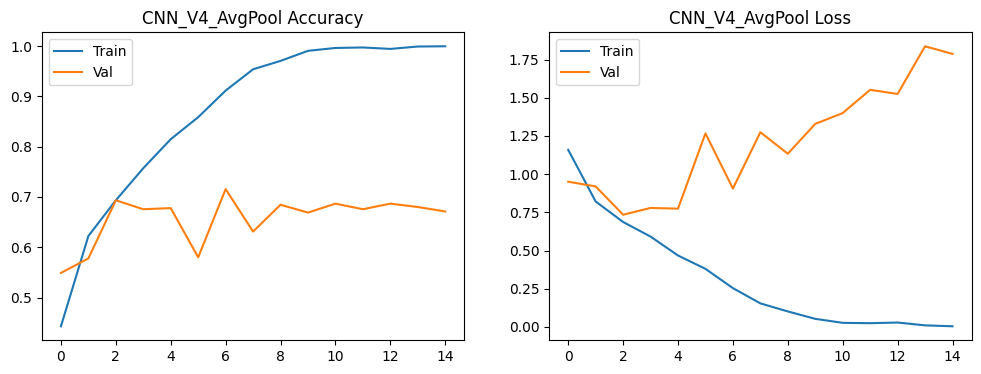

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


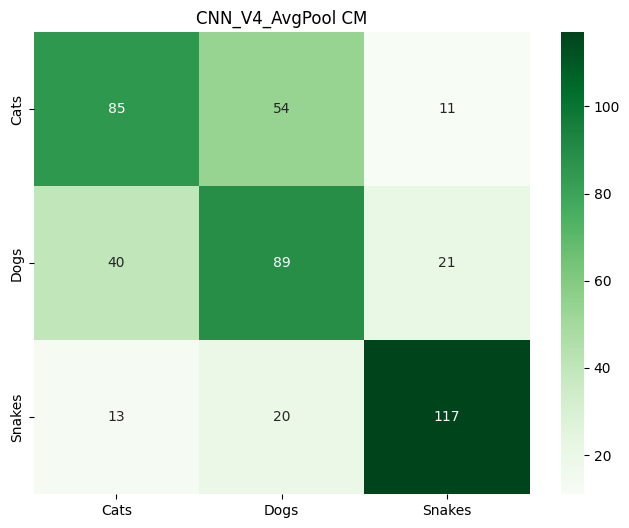


🚀 Starting CNN Experiment: CNN_V5_Optimized...
Epoch 1/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 16s 208ms/step - accuracy: 0.5171 - loss: 4.5640 - val_accuracy: 0.4111 - val_loss: 2.7113
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 203ms/step - accuracy: 0.6161 - loss: 0.8390 - val_accuracy: 0.3489 - val_loss: 4.7075
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 204ms/step - accuracy: 0.6861 - loss: 0.7428 - val_accuracy: 0.3467 - val_loss: 4.3244
Epoch 4/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 204ms/step - accuracy: 0.6937 - loss: 0.7132 - val_accuracy: 0.3511 - val_loss: 1.7679
Epoch 5/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 204ms/step - accuracy: 0.7088 - loss: 0.6522 - val_accuracy: 0.4067 - val_loss: 1.6165
Epoch 6/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 203ms/step - accuracy: 0.7219 - loss: 0.5750 - val_accuracy: 0.4089 - val_loss: 2.1937
Epoch 7/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 204ms/step - accuracy: 0.7532 - loss: 0.5640 - val_accuracy: 0.5822 - val_loss: 1.4466
Epoch 8/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 204ms/s

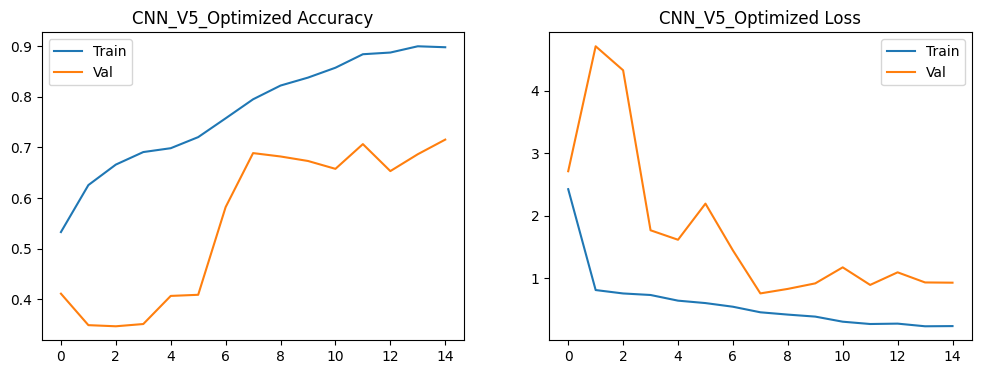

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step


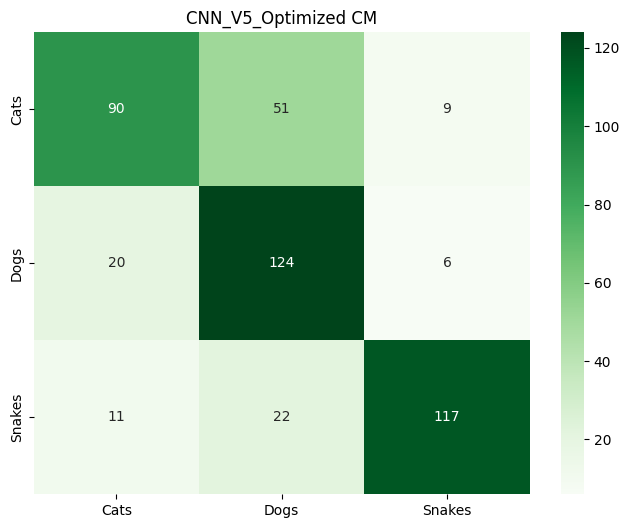

✨ All CNN experiments completed successfully!


In [3]:
# --- STEP 3: Training (15 Epochs per experiment) ---
# --- ADIM 3: Eğitim (Her deney için 15 Epok) ---

cnn_summary = []

for exp in experiments:
    print(f"\n🚀 Starting CNN Experiment: {exp['name']}...")
    model = build_cnn(exp)
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=15, # As requested / İstediğin gibi 15 epok
        batch_size=32,
        verbose=1
    )
    
    # Evaluation / Değerlendirme
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"✅ {exp['name']} Accuracy: {test_acc:.4f}")
    
    cnn_summary.append({**exp, "Accuracy": test_acc, "Loss": test_loss})
    
    # Save Training History Plots / Eğitim Geçmişini Kaydet
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Val')
    plt.title(f"{exp['name']} Accuracy")
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')
    plt.title(f"{exp['name']} Loss")
    plt.legend()
    
    plt.savefig(f"{RESULTS_DIR}/{exp['name']}_history.png")
    plt.show()

    # Confusion Matrix / Karmaşıklık Matrisi
    y_pred = np.argmax(model.predict(X_test), axis=1)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Greens')
    plt.title(f"{exp['name']} CM")
    plt.savefig(f"{RESULTS_DIR}/{exp['name']}_cm.png")
    plt.show()
    
    model.save(f"models/Efe_Yasar_{exp['name']}.keras")

print("✨ All CNN experiments completed successfully!")

In [4]:
# --- STEP 4: Reporting Results --- 
# --- ADIM 4: Sonuçların Raporlanması ---

df_cnn = pd.DataFrame(cnn_summary)
df_cnn.to_csv(f"{RESULTS_DIR}/cnn_comparison_summary.csv", index=False)
print("📝 CNN Comparison Table:")
print(df_cnn[['name', 'Accuracy', 'Loss', 'kernel_size', 'pooling']])

📝 CNN Comparison Table:
                 name  Accuracy      Loss kernel_size pooling
0         CNN_V1_Base  0.671111  1.914275      (3, 3)     max
1  CNN_V2_LargeKernel  0.657778  2.364074      (5, 5)     max
2         CNN_V3_Deep  0.722222  1.150561      (3, 3)     max
3      CNN_V4_AvgPool  0.646667  1.979198      (3, 3)     avg
4    CNN_V5_Optimized  0.735556  0.835869      (3, 3)     max
